*Name*: **Abhi Mondal**     
*Roll No*: **22MS075**

In [1]:
# packages
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.optimize import curve_fit

# Question 1

In [2]:
# parameters
N_values = np.array([50,100, 200, 300, 400, 600, 800, 1000, 5000]) # population size
N_T = 100 # number of trials

u1 = 0.003 # mutation rate for type 0
u2 = 0.001 # mutation rate for type 1

# ideal 
x_star = u2/(u1+u2)
y_star = u1/(u1+u2)

In [3]:
print(f"Ideal frequency for type 0 is {x_star} and ideal frequency for type 1 is {y_star}")

Ideal frequency for type 0 is 0.25 and ideal frequency for type 1 is 0.75


In [4]:
# this code is to estimate the best time for each value of N
# it will take some time to run this code ...
print("Please wait... it will take some time!")


T_Max = 100000 # max time which this code will check 
window = 2000 # the window over which it takes avg while calculating the frequency
eps = 1e-2 # tolerance from the previous frequency 
eps_theory = 1e-2 # tolerance from the theory

# main body
N_T_dic = {}
for N in N_values: # check for all value of N
    
    T_arr = [] # store all value of estimated T for N_T trials to take an avg
    
    for _ in range(N_T):
        population = np.array([0]*(N//2) + [1]*(N//2)) # initial pop
        np.random.shuffle(population)
    
        freq1_history = []
        t = 0 # index
    
        while t < T_Max:
    
            # mutation step
            pop0 = (population == 0)
            rand0 = np.random.rand(N)
            population[pop0 & (rand0 < u1)] = 1
    
            pop1 = (population == 1)
            rand1 = np.random.rand(N)
            population[pop1 & (rand1 < u2)] = 0
    
            # record frequency
            freq1 = np.mean(population == 1)
            freq1_history.append(freq1)
    
            # check equilibration
            if t > 2 * window:
                # comparison between two window of data 
                recent = np.mean(freq1_history[-window:])
                previous = np.mean(freq1_history[-2*window:-window])
    
                if abs(recent - previous) < eps and abs(recent - y_star) < eps_theory: # converging condition
                    break
    
            t += 1 # else index increment
    
        T_arr.append(t)
    
    N_T_dic[N] = int(np.ceil(np.mean(T_arr))) # dictionary to acess the time by the value of N in N_values
    print(f"{N} = {N_T_dic[N]}")

Please wait... it will take some time!
50 = 7626
100 = 6291
200 = 5502
300 = 5095
400 = 4694
600 = 4723
800 = 4618
1000 = 4484
5000 = 4338


In [5]:
# refinement for good looking 
for key in N_T_dic:
    N_T_dic[key] = (N_T_dic[key] // 100)*100 + 100
    print(f"{key} = {N_T_dic[key]}")

50 = 7700
100 = 6300
200 = 5600
300 = 5100
400 = 4700
600 = 4800
800 = 4700
1000 = 4500
5000 = 4400


In [6]:
# this code will take some time so please wait... 
# This will calculate all the frequency using the estimated time and for all value of N_values for N_T times
print("Please wait... it will take some time!")
freq0  = np.zeros((len(N_values),N_T))
freq1 = np.zeros((len(N_values),N_T))
for i,N in enumerate(N_values):
    for j in range(N_T):
        population = np.array([0]*(N//2) + [1]*(N//2))
        np.random.shuffle(population)
        T = N_T_dic[N] # required time for equilibrium 
        for t in range(T):
            pop0 = (population == 0) # find the type 0
            rand0 = np.random.rand(N) 
            population[pop0 & (rand0 < u1)] = 1 # mutations 0 -> 1
        
            pop1 = (population == 1)
            rand1 = np.random.rand(N)
            population[pop1 & (rand1 < u2)] = 0 #mutation 1-> 0
        
        freq0[i,j] = np.mean(population == 0)
        freq1[i,j] = np.mean(population == 1)

Please wait... it will take some time!


In [7]:
# mean frequency -> used the predefined function in numpy same as mentioned in slide 
freq0_mean = np.mean(freq0,axis = 1)
freq1_mean = np.mean(freq1,axis = 1)
# variance -> used the predefined function in numpy same as mentioned in slide 
freq0_var = np.var(freq0,axis = 1)
freq1_var = np.var(freq1,axis = 1)

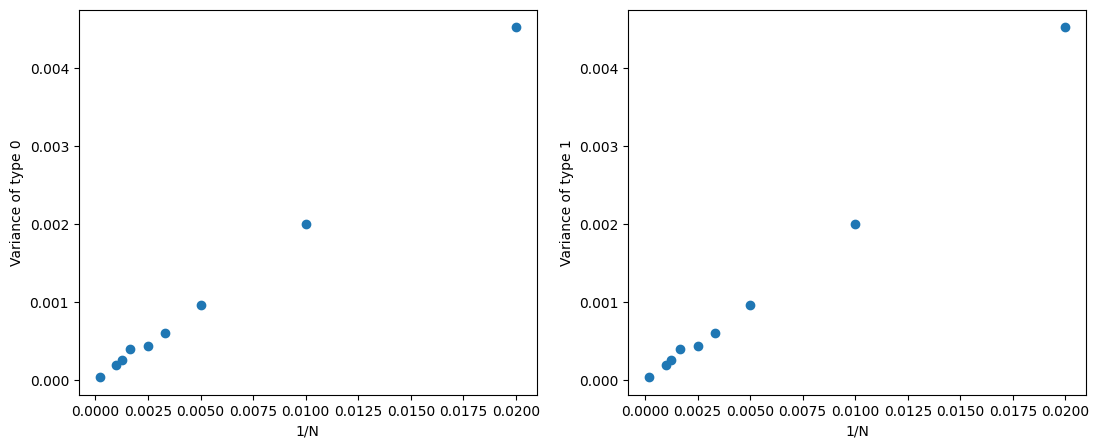

In [8]:
inv_N = 1/N_values # inverse it 

# plotting 
fig, axs = plt.subplots(1,2, figsize = (13,5))

axs = axs.flatten()
axs[0].scatter(inv_N,freq0_var)
axs[0].set_xlabel("1/N")
axs[0].set_ylabel("Variance of type 0")
axs[1].scatter(inv_N,freq1_var)
axs[1].set_xlabel("1/N")
axs[1].set_ylabel("Variance of type 1")
plt.show()

Standard Error in type 0 plot: m_error = 0.005649928655092393, c_error = 4.4076742486090815e-05
Standard Error in type 1 plot: m_error = 0.005649928655092393, c_error = 4.4076742486090815e-05


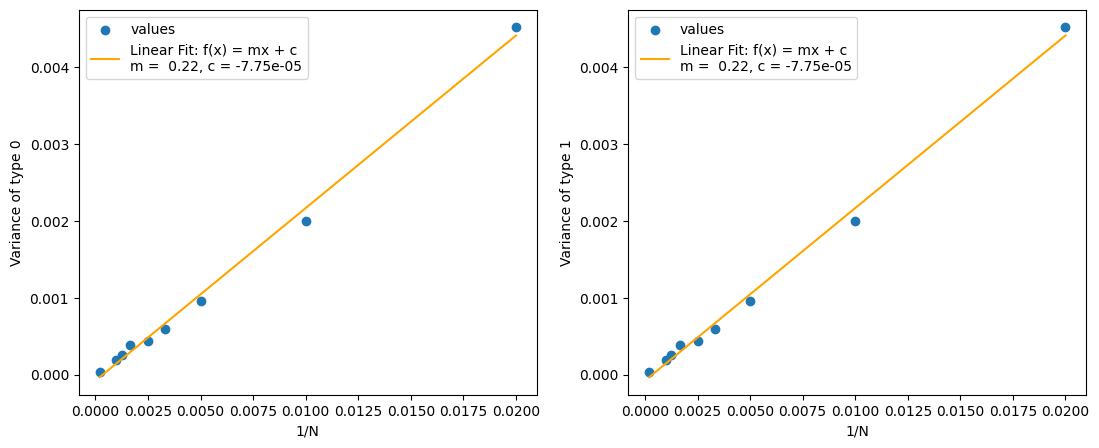

In [9]:
# fitting 
#st line equation
def stLine(x, p1, p2):
    return p1 * x + p2

#plotting
fig, axs = plt.subplots(1,2, figsize = (13,5))

axs = axs.flatten()
axs[0].scatter(inv_N,freq0_var, label = "values")
params, pcov = curve_fit(stLine, inv_N, freq0_var)
axs[0].plot(inv_N, stLine(inv_N,*params), color ='orange', label = f"Linear Fit: f(x) = mx + c\nm = {params[0]: .2f}, c = {params[1]: .2e}")
axs[0].set_xlabel("1/N")
axs[0].set_ylabel("Variance of type 0")
axs[0].legend(loc = "best")
perr = np.sqrt(np.diag(pcov))
print(f"Standard Error in type 0 plot: m_error = {perr[0]}, c_error = {perr[1]}")

axs[1].scatter(inv_N,freq1_var, label = "values")
params, pcov = curve_fit(stLine, inv_N, freq1_var)
axs[1].plot(inv_N, stLine(inv_N,*params), color = 'orange', label = f"Linear Fit: f(x) = mx + c\nm = {params[0]: .2f}, c = {params[1]: .2e}")
axs[1].set_xlabel("1/N")
axs[1].set_ylabel("Variance of type 1")
axs[1].legend(loc = "best")
print(f"Standard Error in type 1 plot: m_error = {perr[0]}, c_error = {perr[1]}")

plt.show()

# Question 2

In [10]:
# parameters
N = 500
fit_0 = 1.0
fit_1 = 1.0     

# relative fitness
f0 = fit_0 / (fit_0 + fit_1)
f1 = fit_1 / (fit_0 + fit_1)

freq_0 = []
freq_1 = []

In [11]:
population = np.array([0]*(N//2) + [1]*(N//2)) #initial pop
np.random.shuffle(population)

In [12]:
# this code will run untill one type remove another one completely
print("Please wait... it will take some time!")

t = 0

while np.any(population == 0) and np.any(population == 1):

    # record freq
    freq_1.append(np.mean(population == 1))
    freq_0.append(1 - freq_1[-1])

    # parent
    parent_index = np.random.randint(N)
    parent_type = population[parent_index]

    r = np.random.rand()

    # reproduction fitness 
    if parent_type == 0 and r > f0:
        continue  # reproduction rejected
    if parent_type == 1 and r > f1:
        continue  # reproduction rejected

    # death index 
    death_index = np.random.randint(N)

    # death is replaced by birth
    population[death_index] = parent_type

    t += 1

# last freq
freq_1.append(np.mean(population == 1))
freq_0.append(1 - freq_1[-1])

Please wait... it will take some time!


fixation time = 70233 Moran steps
final state: 
type 0 frequency = 1.0
type 1 frequency = 0.0


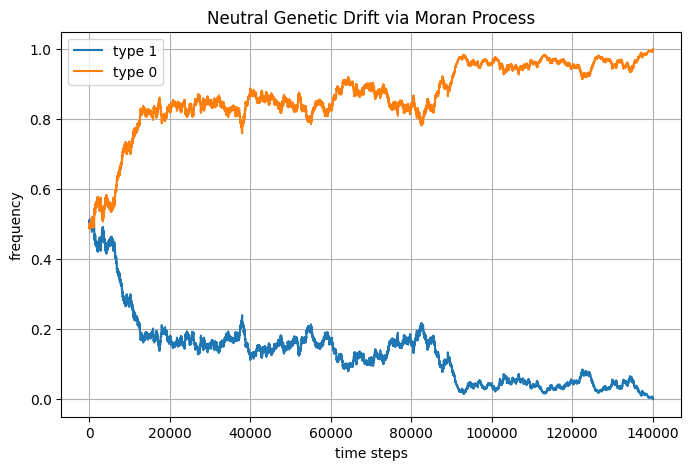

In [13]:
print(f"fixation time = {t} Moran steps")
print(f"final state: \ntype 0 frequency = {freq_0[-1]}\ntype 1 frequency = {freq_1[-1]}")

# plotting
plt.figure(figsize=(8,5))
plt.plot(freq_1, label="type 1")
plt.plot(freq_0, label="type 0")
plt.xlabel("time steps")
plt.ylabel("frequency")
plt.title("Neutral Genetic Drift via Moran Process")
plt.legend(loc = "best")
plt.grid(True)
plt.show()

In [14]:
# parameters
N_T = 100 # number of trial
N = 500
fit_0 = 1.0
fit_1 = 1.0     

# relative fitness
f0 = fit_0 / (fit_0 + fit_1)
f1 = fit_1 / (fit_0 + fit_1)

fix_0 = np.zeros(N_T)
fix_1 = np.zeros(N_T)

In [15]:
# this will run for N_T time to check when type 0 is fixed and when type 1 is fixed to find the prob of fixation
print("Please wait... it will take some time!")

for i in range(N_T):
    freq_0 = []
    freq_1 = []
    t = 0
    population = np.array([0]*(N//2) + [1]*(N//2)) #initial pop
    np.random.shuffle(population)
    while np.any(population == 0) and np.any(population == 1):
    
        # record freq
        freq_1.append(np.mean(population == 1))
        freq_0.append(1 - freq_1[-1])
    
        # parent
        parent_index = np.random.randint(N)
        parent_type = population[parent_index]
    
        r = np.random.rand()
    
        # reproduction fitness 
        if parent_type == 0 and r > f0:
            continue  # reproduction rejected
        if parent_type == 1 and r > f1:
            continue  # reproduction rejected
    
        # death index
        death_index = np.random.randint(N)
    
        population[death_index] = parent_type
    
        t += 1
    
    # last freq
    freq_1.append(np.mean(population == 1))
    freq_0.append(1 - freq_1[-1])
    fix_0[i] = freq_0[-1]
    fix_1[i] = freq_1[-1]

Please wait... it will take some time!


In [16]:
fix_0_prob = np.mean(fix_0 == 1)
fix_1_prob = np.mean(fix_1 == 1)
print(f"Fixation probability of type 0 is {fix_0_prob}\nFixation probability of type 1 is {fix_1_prob}")

Fixation probability of type 0 is 0.48
Fixation probability of type 1 is 0.52


As it is natural evolution, so the fixation probability for both the type should be 0.5, which means they has equal chances to be fixed in the population.